In this notebook I want to compare our model with traditional machine learning models on PCA-selected features (1640 + **881 drug features**) 5 times and report the results in the form of average over results of these 5 times.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Required packages

In [ ]:
pip install xgboost

In [ ]:
import sys
import gc

import csv
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import random
from random import sample, shuffle

from sklearn.utils import shuffle as sk_shuffle

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import KFold

from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.callbacks import  History

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost

In [ ]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Data prepation

## Loading train-test dataset

In [ ]:
with open(r'/content/drive/MyDrive/Dataset19.txt') as f:
    data = []
    for line in f.readlines():
        row = []
        for elem in line.split(sep=','):
            row.append(int(elem.strip()))
        data.append(row)
print(len(data))
print(len(data[0]))

In [ ]:
#Reading phenotypes file
with open(r'/content/drive/MyDrive/drugLabel19.txt') as fy:
    labels = []
    drugs = [] #stores drug name in each row
    row = 0 # row number of each label (is needed because data is reordered while spliting)
    reader = csv.reader(fy)
    for i in reader:
        labels.append([row, int(i[1])])
        drugs.append(i[0])
        row += 1

print(len(labels))
print(len(drugs))
print(labels[:5])

7207
7207
[[0, 1], [1, 1], [2, 0], [3, 0], [4, 1]]


In [ ]:
labels = np.asarray(labels)

# Loading PCA-based features

In [ ]:
pca_selection = []
with open("/content/drive/MyDrive/Master_new_Sep/Revise/PCA_selected_features.txt") as f:
  for i in f.readlines():
    pca_selection.append(int(i.strip()))

print(len(pca_selection))

1640


In [ ]:
data_np = np.asarray(data)

pca_selected_features_set = set(pca_selection)

features_from_8005 = [j for j in range(data_np.shape[1]) if j >= 8005]

all_selected_indices = sorted(list(pca_selected_features_set.union(features_from_8005)))

data_pca = data_np[:, all_selected_indices]

print(len(data_pca))
print(len(data_pca[0]))

7207
2521


In [ ]:
del data_np
data = data_pca
del data_pca

In [ ]:
data = data.tolist()

### Removing duplicates

In [ ]:
duplicate = any(data.count(element) > 1 for element in data)
duplicate

True

In [ ]:
l = [data.count(element) > 1 for element in data]
l[:10]

[True, False, False, True, False, False, True, False, False, True]

In [ ]:
len([i for i in l if i==True])

983

In [ ]:
reps = {}
for element in data:
  if np.asarray(element).tobytes() not in reps.keys():
    num = data.count(element)
    if num > 1:
      reps[np.asarray(element).tobytes()] = num

In [ ]:
len(reps.keys())

403

In [ ]:
reps.values()

dict_values([2, 2, 4, 3, 2, 2, 4, 3, 2, 3, 3, 3, 2, 2, 2, 5, 2, 2, 2, 5, 3, 3, 2, 2, 2, 2, 3, 2, 3, 5, 2, 2, 2, 2, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 3, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 3, 4, 3, 4, 3, 2, 3, 2, 2, 2, 3, 5, 2, 2, 2, 2, 4, 2, 3, 3, 4, 3, 2, 3, 3, 2, 3, 2, 2, 2, 2, 2, 3, 2, 4, 3, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 5, 3, 3, 3, 2, 3, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3, 5, 3, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 5, 2, 2, 2, 3, 4, 2, 2, 3, 2, 3, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 4, 3, 2, 2, 2, 2, 5, 3, 2, 2, 2, 2, 4, 3, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 3, 2, 2, 2, 2, 5, 3, 2, 5, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4, 2, 2, 3, 2, 2, 4, 2, 2, 2, 2, 2, 5, 2, 2, 3, 2, 4, 5, 3, 2, 5, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 3, 5, 2, 2, 2, 3, 5, 2, 2, 5, 2, 2, 2, 5, 3, 2, 2, 2, 3, 2, 2, 2, 4, 2, 2, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 4, 2, 2, 

In [ ]:
sum(reps.values())

983

In [ ]:
print(len(data))
print( sum(reps.values()) )
print(len(reps.keys()))
print(len(data) - sum(reps.values()) + len(reps.keys()))

7207
983
403
6627


In [ ]:
added = []
data_unique = []
drugs_unique = []

labels_unique = []
for idx, element in enumerate(data):
  if np.asarray(element).tobytes() not in added:
    added.append(np.asarray(element).tobytes())
    data_unique.append(element)
    labels_unique.append(labels[idx])
    drugs_unique.append(drugs[idx])

len(data_unique)

6627

In [ ]:
orig_data = data_unique
orig_labels = labels_unique

In [ ]:
del data_unique
len(orig_data)

6627

In [ ]:
del labels_unique
len(orig_labels)

6627

In [ ]:
duplicate = any(orig_data.count(element) > 1 for element in orig_data)
duplicate

False

### A survey on data

In [ ]:
unq_drugs = set(drugs)
len(unq_drugs)

12

In [ ]:
per_drug_dic = {}
for i in orig_labels:
  drug = drugs[i[0]]
  label = i[1]
  if drug not in per_drug_dic.keys():
    per_drug_dic[drug] = [0, 0]  # num of resistant, num of susceptible
  if label == 0:
    per_drug_dic[drug][1] += 1
  else:
    per_drug_dic[drug][0] += 1

per_drug_dic

{'gentamicin': [572, 94],
 'levofloxacin': [459, 146],
 'ceftazidime': [526, 105],
 'imipenem': [195, 508],
 'tetracycline': [511, 182],
 'amikacin': [299, 394],
 'cefotaxime': [568, 31],
 'ciprofloxacin': [650, 97],
 'ceftriaxone': [633, 34],
 'meropenem': [165, 173],
 'doripenem': [51, 148],
 'moxifloxacin': [57, 29]}

## Train-Test split

In [ ]:
def balanced_train_test_split(data, labels, drugs, n, rs):
  """
  Performs a train_test_split, setting n susceptibles and n resistant strains aside for each drug
  returns x_train, x_test, y_train, y_test
  """

  data, labels = sk_shuffle(data, labels, random_state=rs)

  x_train = []
  x_test = []
  y_train = []
  y_test = []

  idx = {} # A dic containig indices of susceptible and resistant strain
            # for each drug

  unq_drugs = list(set(drugs))

  for drug_name in unq_drugs:
    drug_indx_S = []
    drug_indx_R = []
    for i in range(len(labels)):
      j, l = labels[i][0], labels[i][1]
      if drugs[j] == drug_name:
        if l == 0:
          drug_indx_S.append(i)
        else:
          drug_indx_R.append(i)
    idx[(drug_name, 'S')] = drug_indx_S
    idx[(drug_name, 'R')] = drug_indx_R

  len_xtrain = 0
  len_xtest = 0

  for drug in unq_drugs:

    s_set = idx[(drug, 'S')]
    for i in range(len(s_set)-n):
      x_train.append(data[s_set[i]])
      y_train.append(labels[s_set[i]])
    for i in range(1, n+1):
      x_test.append(data[s_set[-i]])
      y_test.append(labels[s_set[-i]])

    r_set = idx[(drug, 'R')]
    for i in range(len(r_set)-n):
      x_train.append(data[r_set[i]])
      y_train.append(labels[r_set[i]])
    for i in range(1, n+1):
      x_test.append(data[r_set[-i]])
      y_test.append(labels[r_set[-i]])

    # For confirming it's working properly
    print("for drug ", drug, "# of train samples: ", len(x_train)-len_xtrain, )
    len_xtrain = len(x_train)
    print("for drug ", drug, "# of test samples: ", len(x_test)-len_xtest)
    len_xtest = len(x_test)

  return x_train, x_test, y_train, y_test

In [ ]:
def make_balanced_triplets(samples, labels, drugs, num):
  """For each drug in drugs samples...
  makes:
  - n triplets which are both Susceptible to drug (S, S)
  - n triplets which are (R, R)
  - n triplets which are (S, R)
  - n triplets which are (R, S)
  """
  bac_shape = 1640

  idx = {} # A dic containig indices of susceptible and resistant strain
            # for each drug

  triplet = [] # Made from samples which are not part of external_test_sets
  triLabels = [] # Labels corresponding to triplets

  unq_drugs = list(set(drugs))

  for drug_name in unq_drugs:
    drug_indx_S = []
    drug_indx_R = []
    for i in range(len(labels)):
      j, l = labels[i][0], labels[i][1]
      if drugs[j] == drug_name:
        if l == 0:
          drug_indx_S.append(i)
        else:
          drug_indx_R.append(i)
    idx[(drug_name, 'S')] = drug_indx_S
    idx[(drug_name, 'R')] = drug_indx_R

  for drug in unq_drugs:

    s_len = len(idx[(drug, 'S')])
    r_len = len(idx[(drug, 'R')])
    n = min(num, int(s_len*(s_len-1)/2), int(r_len*(r_len-1)/2))

    ss = [(i, j) for i in idx[(drug, 'S')] for j in idx[(drug, 'S')] if j>i]
    ss_sampled = sample(ss, n)

    rr = [(i, j) for i in idx[(drug, 'R')] for j in idx[(drug, 'R')] if j>i]
    rr_sampled = sample(rr, n)

    rs = [(i, j) for i in idx[(drug, 'R')] for j in idx[(drug, 'S')]]
    neg_samples = sample(rs, 2*n)
    rs_sampled = neg_samples[:n]
    sr_sampled = [(t[1], t[0]) for t in neg_samples[n:]]

    for k in range(n):
      # Making (S, S, d) triplets
      triplet.append( samples[ss_sampled[k][0]][:bac_shape] + samples[ss_sampled[k][1]][:bac_shape] +
                        samples[ss_sampled[k][0]][bac_shape:] )
      triLabels.append([1, 0]) # 1: both phenos the same. First: 0, sencond? --> 0

      # Making (R, R, d) triplets
      triplet.append( samples[rr_sampled[k][0]][:bac_shape] + samples[rr_sampled[k][1]][:bac_shape] +
                        samples[rr_sampled[k][0]][bac_shape:] )
      triLabels.append([1, 1]) # 1: both phenos the same. First: 1, sencond? --> 1

      # Making (R, S, d) triplets
      triplet.append( samples[rs_sampled[k][0]][:bac_shape] + samples[rs_sampled[k][1]][:bac_shape] +
                         samples[rs_sampled[k][0]][bac_shape:])
      triLabels.append([0, 1]) # 0: phenos different. First: 1, sencond? --> 0

      # Making (S, R, d) triplets
      triplet.append( samples[sr_sampled[k][0]][:bac_shape] + samples[sr_sampled[k][1]][:bac_shape] +
                         samples[sr_sampled[k][0]][bac_shape:])
      triLabels.append([0, 0]) # 0: phenos different. First: 0, sencond? --> 1

  return np.array(triplet), np.array(triLabels)

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 42)

for drug  imipenem # of train samples:  693
for drug  imipenem # of test samples:  10
for drug  amikacin # of train samples:  683
for drug  amikacin # of test samples:  10
for drug  meropenem # of train samples:  328
for drug  meropenem # of test samples:  10
for drug  gentamicin # of train samples:  656
for drug  gentamicin # of test samples:  10
for drug  cefotaxime # of train samples:  589
for drug  cefotaxime # of test samples:  10
for drug  moxifloxacin # of train samples:  76
for drug  moxifloxacin # of test samples:  10
for drug  tetracycline # of train samples:  683
for drug  tetracycline # of test samples:  10
for drug  doripenem # of train samples:  189
for drug  doripenem # of test samples:  10
for drug  ceftriaxone # of train samples:  657
for drug  ceftriaxone # of test samples:  10
for drug  levofloxacin # of train samples:  595
for drug  levofloxacin # of test samples:  10
for drug  ceftazidime # of train samples:  621
for drug  ceftazidime # of test samples:  10
for dru

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
print(len(triplet))
print(len(triplet[0]))
print(len(pairedLabels))
print(pairedLabels[0])

18404
4161
18404
[1 0]


In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

# Evaluation functions

In [ ]:
def evaluation(true_labels, pred_labels):

  Dis_pred = []
  for i in pred_labels:
    if i < 0.5:
      Dis_pred.append(0)
    else:
      Dis_pred.append(1)

  acc = accuracy_score(true_labels, Dis_pred)
  auc = roc_auc_score(true_labels, Dis_pred)
  print('Accuracy: ', acc)
  print('ROC-AUC: ', auc)

  TN, FP, FN, TP = confusion_matrix(true_labels, Dis_pred, labels=[0, 1]).ravel()
  sen = TP/(TP+FN)
  spc = TN/(TN+FP)
  print("Sensitivity: ", sen)
  print('Specificity: ', spc)

  conf_matrix = confusion_matrix(true_labels, Dis_pred, labels=[0, 1])
  plt.figure(figsize=(4, 4))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=['Predicted Negative', 'Predicted Positive'],
              yticklabels=['True Negative', 'True Positive'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

  return acc, auc, sen, spc

# Deep model architecture

In [ ]:
def create_siamese_model(input_shape1, input_shape2, input_shape3):

    right_input = Input(shape=input_shape2)
    left_input = Input(shape=input_shape1)
    third_input = Input(shape=input_shape3)

    shared_layer1 = Dense(1024, activation='leaky_relu')
    shared_layer2 = Dense(512, activation='leaky_relu')
    shared_layer3 = Dense(256, activation='leaky_relu')
    shared_bn = BatchNormalization() # shared batch normalization layer
    drug_bn = BatchNormalization() # drug batch normalization layer

    encoded_l = shared_layer1(left_input)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_layer2(encoded_l)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_layer3(encoded_l)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_bn(encoded_l)

    encoded_r = shared_layer1(right_input)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_layer2(encoded_r)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_layer3(encoded_r)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_bn(encoded_r)

    encoded_c = Dense(512, activation='leaky_relu')(third_input)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = Dense(256, activation='leaky_relu')(encoded_c)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = drug_bn(encoded_c)

    concatenated = Concatenate()([encoded_l, encoded_r, encoded_c])

    dense1 = Dense(512, activation='leaky_relu')(concatenated)
    dense1 = Dropout(0.2)(dense1)
    dense2 = Dense(128, activation='leaky_relu')(dense1)
    dense2 = Dropout(0.2)(dense2)
    prediction = Dense(1, activation='sigmoid')(dense2)

    siamese_net = Model(inputs=[left_input, right_input, third_input], outputs=prediction)

    optimizer = Adam(learning_rate=0.001)
    siamese_net.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=["accuracy", AUC(name='auc-roc')])

    return siamese_net

# Evaluations

## Functions
Performance on queries

So each label is a list of size 2

In [ ]:
def ExternalTest(x0_test,x1_test,x0_train,x1_train):
  """
  Takes as input paired data and
  makes each test sample pair with train samples of the same drug (triplet --> b1, b2, d).
  x0_test: test samples with phenotype 0
  x1_test: test samples with phenotype 1
  x0_train: train samples with phenotype 0
  x1_train: train samples with phenotype 1
  """
  dataset_test1=[] # concat train
  label_test1=[]
  Indexsample=[]

  for i in range(len(x0_test)):
    for j in range(len(x0_train)):
      if (x0_test[i][1640:] == x0_train[j][1640:]).all():
        dataset_test1.append(np.concatenate((x0_test[i][0:1640],x0_train[j]), axis=None))
        label_test1.append(1)
        Indexsample.append(str(i)+",0,0")   #index in test, x0_test pheno, x0_train pheno

  for i in range(len(x0_test)):
    for j in range(len(x1_train)):
      if (x0_test[i][1640:] == x1_train[j][1640:]).all():
        dataset_test1.append(np.concatenate((x0_test[i][0:1640],x1_train[j]), axis=None))
        label_test1.append(0)
        Indexsample.append(str(i)+",0,1")   #index in test, x0_test pheno, x1_train pheno

  for i in range(len(x1_test)):
    for j in range(len(x0_train)):
      if (x1_test[i][1640:] == x0_train[j][1640:]).all():
        dataset_test1.append(np.concatenate((x1_test[i][0:1640],x0_train[j]), axis=None))
        label_test1.append(0)
        Indexsample.append(str(i)+",1,0")  #index in test,x1_test,x0_train

  for i in range(len(x1_test)):
    for j in range(len(x1_train)):
      if (x1_test[i][1640:] == x1_train[j][1640:]).all():
        dataset_test1.append(np.concatenate((x1_test[i][0:1640],x1_train[j]), axis=None))
        label_test1.append(1)
        Indexsample.append(str(i)+",1,1")  #index in test,x1_test,x1_train

  return (np.asarray(dataset_test1), np.asarray(label_test1), Indexsample)

In [ ]:
def DefineTest2(x0_test, x1_test, Indexsample, y_pred):
  Pred=[]
  Label=[]

  # START of x0_test
  for i in range(len(x0_test)):
    cnt0Pred=0
    cnt1Pred=0
    cnt1=0
    cnt0=0

    for j in range(len(Indexsample)):
      triplet=Indexsample[j].split(",")   #pair[0] is index from test, pair[1] identifies which test x0_test or s1_test, pair[2] identifies which x0
      if int(triplet[0])==i: #index test
        if int(triplet[1])==0: #type test

          if int(triplet[2])==1: #type train
              cnt1Pred=cnt1Pred+y_pred[j]
              cnt1=cnt1+1

          if int(triplet[2])==0: #type train
              cnt0Pred=cnt0Pred+y_pred[j]
              cnt0=cnt0+1

    pos=(1-(cnt0Pred/cnt0))+(cnt1Pred/cnt1)
    neg=(cnt0Pred/cnt0)+(1-(cnt1Pred/cnt1))
    Pred.append(pos/(pos+neg))
    Label.append(0)

  # END of x0_test
  ######################################################
  # START of x1_test
  for i in range(len(x1_test)):
    cnt0Pred=0
    cnt1Pred=0
    cnt1=0
    cnt0=0
    for j in range(len(Indexsample)):
      triplet=Indexsample[j].split(",")   #pair[0] is index from test, pair[1] identifies which test x0_test or s1_test, pair[2] identifies which x0
      if int(triplet[0])==i: #index test
        if int(triplet[1])==1: #type test

          if int(triplet[2])==0: #type train
              cnt0Pred=cnt0Pred+y_pred[j]
              cnt0=cnt0+1

          if int(triplet[2])==1: #type train
              cnt1Pred=cnt1Pred+y_pred[j]
              cnt1=cnt1+1

    pos=(1-(cnt0Pred/cnt0))+(cnt1Pred/cnt1)
    neg=(cnt0Pred/cnt0)+(1-(cnt1Pred/cnt1))
    Pred.append(pos/(pos+neg))
    Label.append(1)

  return(Pred,Label)

In [ ]:
def RS_splitter(data, labels):
  """
  Takes as input a dataset and corresponding labels (in terms of list of 0s and 1s)
  returns data0, data1
  which are set of susceptible and resistant strains in data, respectively
  """
  data0 = [] # list of susceptible strains' features
  data1 = [] # list of resistant strains' features

  for i, l in enumerate(labels):
    if l == 0:
      data0.append(data[i])
    else:
      data1.append(data[i])

  return data0, data1

In [ ]:
rf_acc = []
rf_auc = []
rf_sen = []
rf_spc = []

svm_acc = []
svm_auc = []
svm_sen = []
svm_spc = []

xgb_acc = []
xgb_auc = []
xgb_sen = []
xgb_spc = []

nn_acc = []
nn_auc = []
nn_sen = []
nn_spc = []

sim_acc = []
sim_auc = []
sim_sen = []
sim_spc = []

# Round 1
random state: 42

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (1640,)
input_shape2 = (1640,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(18404, 4161)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(18404, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]])

Accuracy:  0.9921212779830472
ROC-AUC:  0.9921212779830471
Sensitivity:  0.9906542056074766
Specificity:  0.9935883503586177


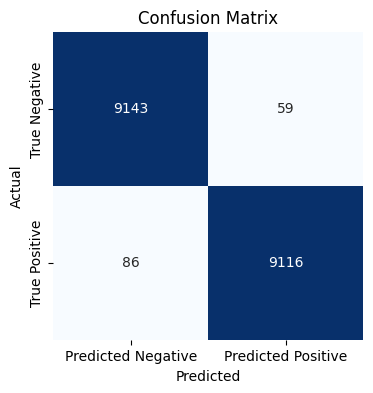

(0.9921212779830472,
 np.float64(0.9921212779830471),
 np.float64(0.9906542056074766),
 np.float64(0.9935883503586177))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.925
ROC-AUC:  0.925
Sensitivity:  0.9666666666666667
Specificity:  0.8833333333333333


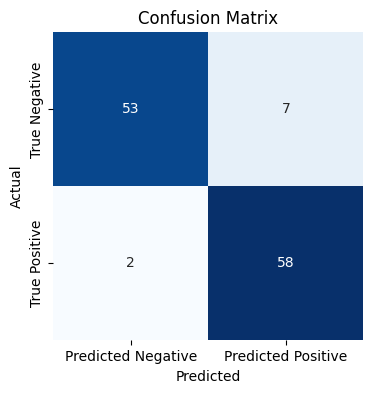

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.925]
[np.float64(0.925)]
[np.float64(0.9666666666666667)]
[np.float64(0.8833333333333333)]


#### SVM

Accuracy:  0.925
ROC-AUC:  0.9249999999999999
Sensitivity:  0.95
Specificity:  0.9


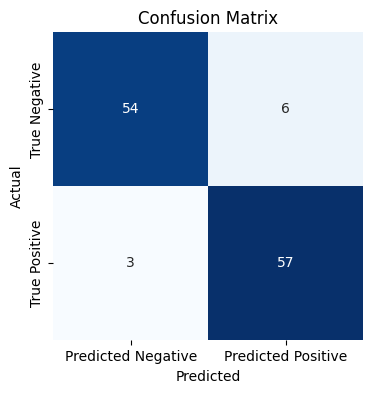

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.925]
[np.float64(0.9249999999999999)]
[np.float64(0.95)]
[np.float64(0.9)]


#### XGBoost

Accuracy:  0.925
ROC-AUC:  0.925
Sensitivity:  0.9666666666666667
Specificity:  0.8833333333333333


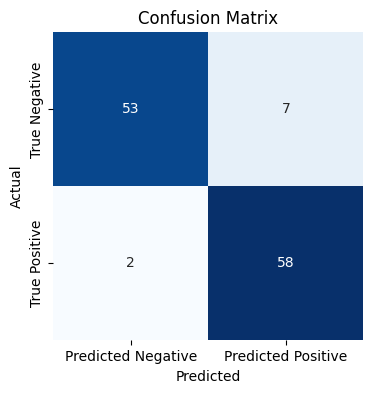

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.925]
[np.float64(0.925)]
[np.float64(0.9666666666666667)]
[np.float64(0.8833333333333333)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

60
2521
60
2521


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1881
2521
4626
2521


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.9235438758260335
ROC-AUC:  0.9235438758260335
Sensitivity:  0.9483633010603965
Specificity:  0.8987244505916705


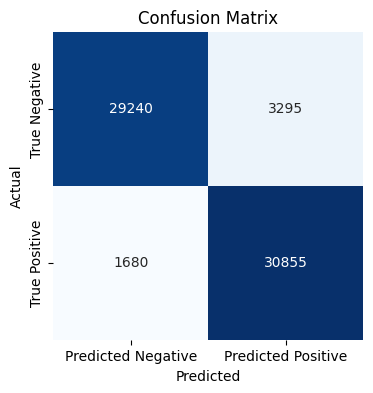

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9235438758260335]
[np.float64(0.9235438758260335)]
[np.float64(0.9483633010603965)]
[np.float64(0.8987244505916705)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.9333333333333333
ROC-AUC:  0.9333333333333335
Sensitivity:  0.9666666666666667
Specificity:  0.9


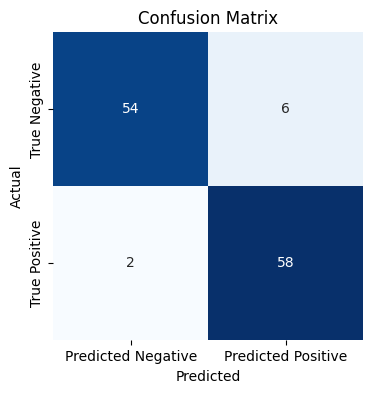

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.9333333333333333]
[np.float64(0.9333333333333335)]
[np.float64(0.9666666666666667)]
[np.float64(0.9)]


# Round 2
random state: 0

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 0)

for drug  imipenem # of train samples:  693
for drug  imipenem # of test samples:  10
for drug  amikacin # of train samples:  683
for drug  amikacin # of test samples:  10
for drug  meropenem # of train samples:  328
for drug  meropenem # of test samples:  10
for drug  gentamicin # of train samples:  656
for drug  gentamicin # of test samples:  10
for drug  cefotaxime # of train samples:  589
for drug  cefotaxime # of test samples:  10
for drug  moxifloxacin # of train samples:  76
for drug  moxifloxacin # of test samples:  10
for drug  tetracycline # of train samples:  683
for drug  tetracycline # of test samples:  10
for drug  doripenem # of train samples:  189
for drug  doripenem # of test samples:  10
for drug  ceftriaxone # of train samples:  657
for drug  ceftriaxone # of test samples:  10
for drug  levofloxacin # of train samples:  595
for drug  levofloxacin # of test samples:  10
for drug  ceftazidime # of train samples:  621
for drug  ceftazidime # of test samples:  10
for dru

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (1640,)
input_shape2 = (1640,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(18404, 4161)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(18404, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]])

Accuracy:  0.9895131493153663
ROC-AUC:  0.9895131493153663
Sensitivity:  0.986198652466855
Specificity:  0.9928276461638774


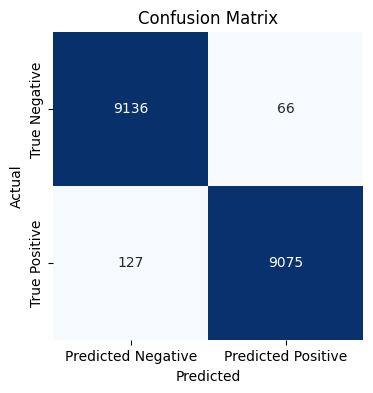

(0.9895131493153663,
 np.float64(0.9895131493153663),
 np.float64(0.986198652466855),
 np.float64(0.9928276461638774))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.9666666666666667
ROC-AUC:  0.9666666666666666
Sensitivity:  0.9833333333333333
Specificity:  0.95


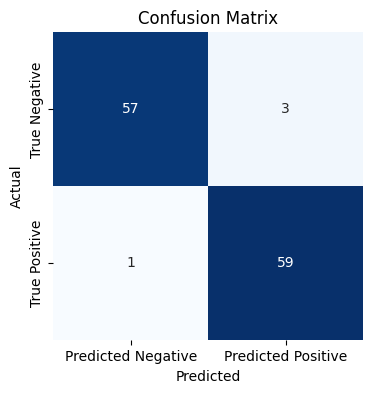

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.925, 0.9666666666666667]
[np.float64(0.925), np.float64(0.9666666666666666)]
[np.float64(0.9666666666666667), np.float64(0.9833333333333333)]
[np.float64(0.8833333333333333), np.float64(0.95)]


#### SVM

Accuracy:  0.9
ROC-AUC:  0.9
Sensitivity:  0.9333333333333333
Specificity:  0.8666666666666667


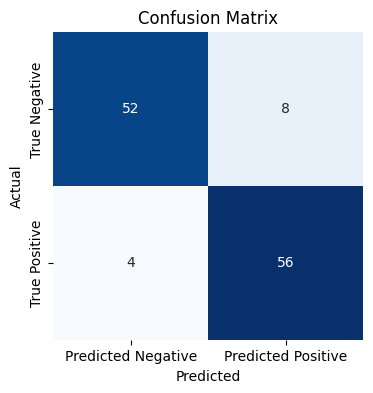

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.925, 0.9]
[np.float64(0.9249999999999999), np.float64(0.9)]
[np.float64(0.95), np.float64(0.9333333333333333)]
[np.float64(0.9), np.float64(0.8666666666666667)]


#### XGBoost

Accuracy:  0.9666666666666667
ROC-AUC:  0.9666666666666666
Sensitivity:  0.9833333333333333
Specificity:  0.95


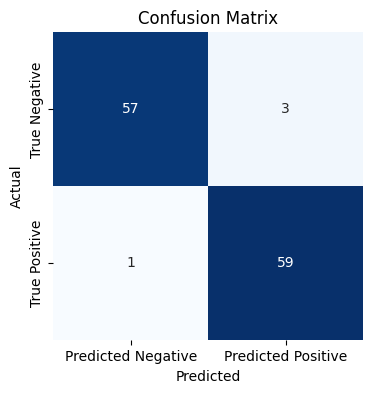

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.925, 0.9666666666666667]
[np.float64(0.925), np.float64(0.9666666666666666)]
[np.float64(0.9666666666666667), np.float64(0.9833333333333333)]
[np.float64(0.8833333333333333), np.float64(0.95)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

60
2521
60
2521


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1881
2521
4626
2521


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.9663285692331336
ROC-AUC:  0.9663285692331335
Sensitivity:  0.9632088520055325
Specificity:  0.9694482864607346


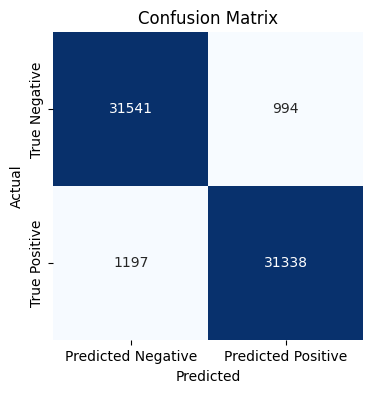

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9235438758260335, 0.9663285692331336]
[np.float64(0.9235438758260335), np.float64(0.9663285692331335)]
[np.float64(0.9483633010603965), np.float64(0.9632088520055325)]
[np.float64(0.8987244505916705), np.float64(0.9694482864607346)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.9666666666666667
ROC-AUC:  0.9666666666666667
Sensitivity:  1.0
Specificity:  0.9333333333333333


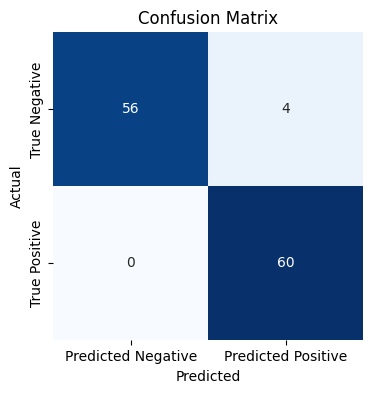

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.9333333333333333, 0.9666666666666667]
[np.float64(0.9333333333333335), np.float64(0.9666666666666667)]
[np.float64(0.9666666666666667), np.float64(1.0)]
[np.float64(0.9), np.float64(0.9333333333333333)]


# Round 3
random state: 123

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 123)

for drug  imipenem # of train samples:  693
for drug  imipenem # of test samples:  10
for drug  amikacin # of train samples:  683
for drug  amikacin # of test samples:  10
for drug  meropenem # of train samples:  328
for drug  meropenem # of test samples:  10
for drug  gentamicin # of train samples:  656
for drug  gentamicin # of test samples:  10
for drug  cefotaxime # of train samples:  589
for drug  cefotaxime # of test samples:  10
for drug  moxifloxacin # of train samples:  76
for drug  moxifloxacin # of test samples:  10
for drug  tetracycline # of train samples:  683
for drug  tetracycline # of test samples:  10
for drug  doripenem # of train samples:  189
for drug  doripenem # of test samples:  10
for drug  ceftriaxone # of train samples:  657
for drug  ceftriaxone # of test samples:  10
for drug  levofloxacin # of train samples:  595
for drug  levofloxacin # of test samples:  10
for drug  ceftazidime # of train samples:  621
for drug  ceftazidime # of test samples:  10
for dru

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (1640,)
input_shape2 = (1640,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(18404, 4161)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(18404, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

In [ ]:
train_pred = siamese_net.predict([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]])

Accuracy:  0.991632253857857
ROC-AUC:  0.991632253857857
Sensitivity:  0.9891327972179961
Specificity:  0.9941317104977179


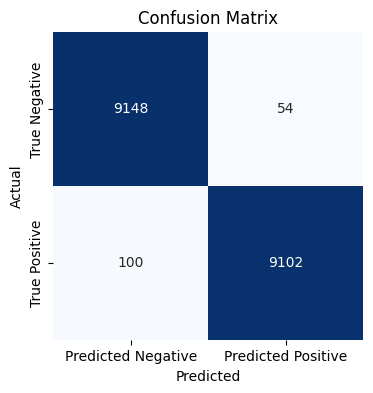

(0.991632253857857,
 np.float64(0.991632253857857),
 np.float64(0.9891327972179961),
 np.float64(0.9941317104977179))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.9333333333333333
ROC-AUC:  0.9333333333333333
Sensitivity:  1.0
Specificity:  0.8666666666666667


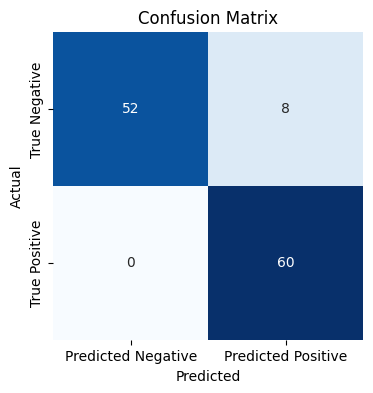

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.925, 0.9666666666666667, 0.9333333333333333]
[np.float64(0.925), np.float64(0.9666666666666666), np.float64(0.9333333333333333)]
[np.float64(0.9666666666666667), np.float64(0.9833333333333333), np.float64(1.0)]
[np.float64(0.8833333333333333), np.float64(0.95), np.float64(0.8666666666666667)]


#### SVM

Accuracy:  0.8916666666666667
ROC-AUC:  0.8916666666666666
Sensitivity:  0.9166666666666666
Specificity:  0.8666666666666667


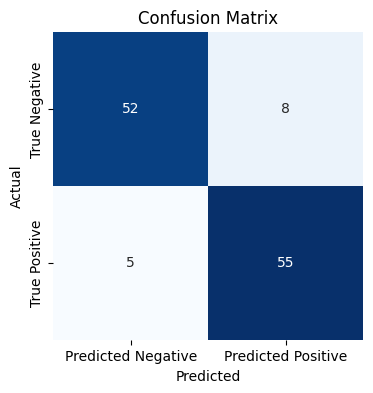

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.925, 0.9, 0.8916666666666667]
[np.float64(0.9249999999999999), np.float64(0.9), np.float64(0.8916666666666666)]
[np.float64(0.95), np.float64(0.9333333333333333), np.float64(0.9166666666666666)]
[np.float64(0.9), np.float64(0.8666666666666667), np.float64(0.8666666666666667)]


#### XGBoost

Accuracy:  0.9416666666666667
ROC-AUC:  0.9416666666666668
Sensitivity:  0.9833333333333333
Specificity:  0.9


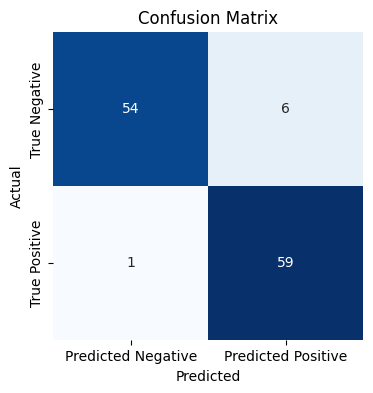

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.925, 0.9666666666666667, 0.9416666666666667]
[np.float64(0.925), np.float64(0.9666666666666666), np.float64(0.9416666666666668)]
[np.float64(0.9666666666666667), np.float64(0.9833333333333333), np.float64(0.9833333333333333)]
[np.float64(0.8833333333333333), np.float64(0.95), np.float64(0.9)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

60
2521
60
2521


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1881
2521
4626
2521


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.8930843706777317
ROC-AUC:  0.8930843706777317
Sensitivity:  0.9597971415398802
Specificity:  0.8263715998155832


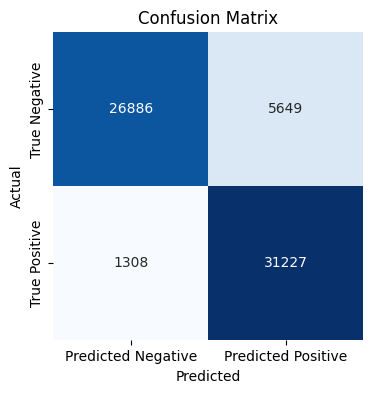

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9235438758260335, 0.9663285692331336, 0.8930843706777317]
[np.float64(0.9235438758260335), np.float64(0.9663285692331335), np.float64(0.8930843706777317)]
[np.float64(0.9483633010603965), np.float64(0.9632088520055325), np.float64(0.9597971415398802)]
[np.float64(0.8987244505916705), np.float64(0.9694482864607346), np.float64(0.8263715998155832)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.9166666666666666
ROC-AUC:  0.9166666666666666
Sensitivity:  0.9833333333333333
Specificity:  0.85


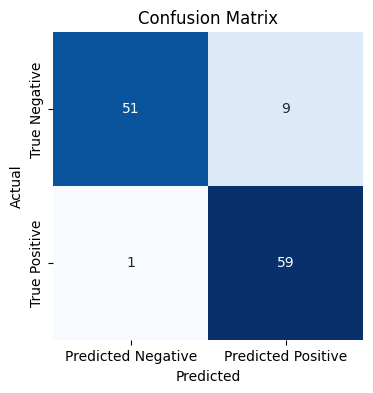

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.9333333333333333, 0.9666666666666667, 0.9166666666666666]
[np.float64(0.9333333333333335), np.float64(0.9666666666666667), np.float64(0.9166666666666666)]
[np.float64(0.9666666666666667), np.float64(1.0), np.float64(0.9833333333333333)]
[np.float64(0.9), np.float64(0.9333333333333333), np.float64(0.85)]


# Round 4
random state: 777

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 777)

for drug  imipenem # of train samples:  693
for drug  imipenem # of test samples:  10
for drug  amikacin # of train samples:  683
for drug  amikacin # of test samples:  10
for drug  meropenem # of train samples:  328
for drug  meropenem # of test samples:  10
for drug  gentamicin # of train samples:  656
for drug  gentamicin # of test samples:  10
for drug  cefotaxime # of train samples:  589
for drug  cefotaxime # of test samples:  10
for drug  moxifloxacin # of train samples:  76
for drug  moxifloxacin # of test samples:  10
for drug  tetracycline # of train samples:  683
for drug  tetracycline # of test samples:  10
for drug  doripenem # of train samples:  189
for drug  doripenem # of test samples:  10
for drug  ceftriaxone # of train samples:  657
for drug  ceftriaxone # of test samples:  10
for drug  levofloxacin # of train samples:  595
for drug  levofloxacin # of test samples:  10
for drug  ceftazidime # of train samples:  621
for drug  ceftazidime # of test samples:  10
for dru

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (1640,)
input_shape2 = (1640,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(18404, 4161)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(18404, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)


In [ ]:
train_pred = siamese_net.predict([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]])

Accuracy:  0.9973918713323191
ROC-AUC:  0.997391871332319
Sensitivity:  0.9964138230819387
Specificity:  0.9983699195826994


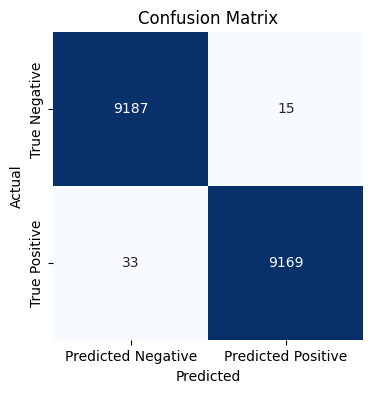

(0.9973918713323191,
 np.float64(0.997391871332319),
 np.float64(0.9964138230819387),
 np.float64(0.9983699195826994))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.9166666666666666
ROC-AUC:  0.9166666666666666
Sensitivity:  0.9333333333333333
Specificity:  0.9


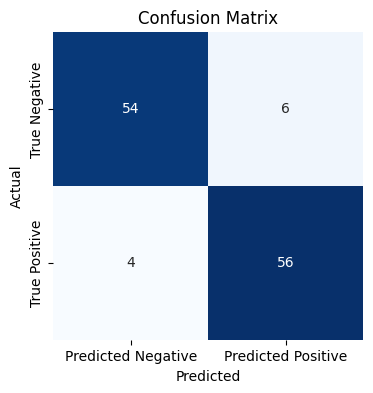

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.925, 0.9666666666666667, 0.9333333333333333, 0.9166666666666666]
[np.float64(0.925), np.float64(0.9666666666666666), np.float64(0.9333333333333333), np.float64(0.9166666666666666)]
[np.float64(0.9666666666666667), np.float64(0.9833333333333333), np.float64(1.0), np.float64(0.9333333333333333)]
[np.float64(0.8833333333333333), np.float64(0.95), np.float64(0.8666666666666667), np.float64(0.9)]


#### SVM

Accuracy:  0.925
ROC-AUC:  0.9249999999999999
Sensitivity:  0.95
Specificity:  0.9


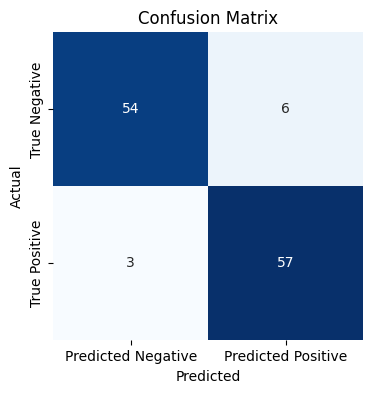

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.925, 0.9, 0.8916666666666667, 0.925]
[np.float64(0.9249999999999999), np.float64(0.9), np.float64(0.8916666666666666), np.float64(0.9249999999999999)]
[np.float64(0.95), np.float64(0.9333333333333333), np.float64(0.9166666666666666), np.float64(0.95)]
[np.float64(0.9), np.float64(0.8666666666666667), np.float64(0.8666666666666667), np.float64(0.9)]


#### XGBoost

Accuracy:  0.9333333333333333
ROC-AUC:  0.9333333333333333
Sensitivity:  0.9333333333333333
Specificity:  0.9333333333333333


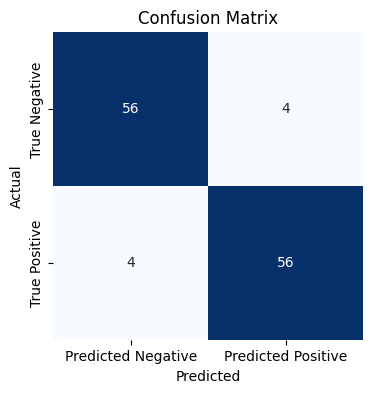

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.925, 0.9666666666666667, 0.9416666666666667, 0.9333333333333333]
[np.float64(0.925), np.float64(0.9666666666666666), np.float64(0.9416666666666668), np.float64(0.9333333333333333)]
[np.float64(0.9666666666666667), np.float64(0.9833333333333333), np.float64(0.9833333333333333), np.float64(0.9333333333333333)]
[np.float64(0.8833333333333333), np.float64(0.95), np.float64(0.9), np.float64(0.9333333333333333)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

60
2521
60
2521


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1881
2521
4626
2521


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.956569847856155
ROC-AUC:  0.956569847856155
Sensitivity:  0.9744275395727678
Specificity:  0.9387121561395421


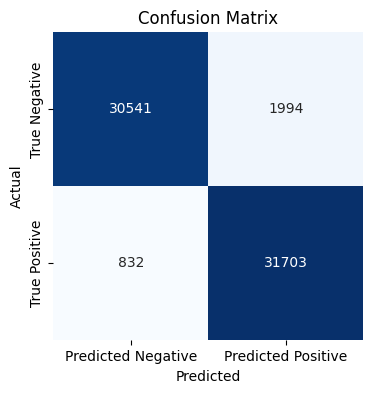

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9235438758260335, 0.9663285692331336, 0.8930843706777317, 0.956569847856155]
[np.float64(0.9235438758260335), np.float64(0.9663285692331335), np.float64(0.8930843706777317), np.float64(0.956569847856155)]
[np.float64(0.9483633010603965), np.float64(0.9632088520055325), np.float64(0.9597971415398802), np.float64(0.9744275395727678)]
[np.float64(0.8987244505916705), np.float64(0.9694482864607346), np.float64(0.8263715998155832), np.float64(0.9387121561395421)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.925
ROC-AUC:  0.9249999999999999
Sensitivity:  0.95
Specificity:  0.9


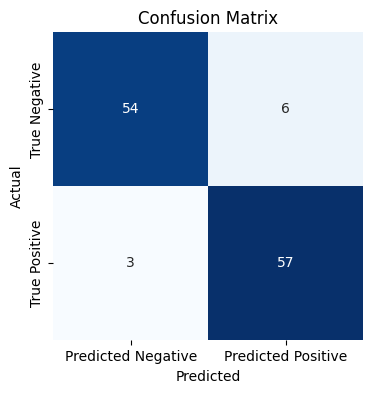

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.9333333333333333, 0.9666666666666667, 0.9166666666666666, 0.925]
[np.float64(0.9333333333333335), np.float64(0.9666666666666667), np.float64(0.9166666666666666), np.float64(0.9249999999999999)]
[np.float64(0.9666666666666667), np.float64(1.0), np.float64(0.9833333333333333), np.float64(0.95)]
[np.float64(0.9), np.float64(0.9333333333333333), np.float64(0.85), np.float64(0.9)]


# Round 5
random state: 111

In [ ]:
# Splitting data
train_set, test_set, train_labels, test_labels = balanced_train_test_split(orig_data, orig_labels, drugs, 5, 111)

for drug  imipenem # of train samples:  693
for drug  imipenem # of test samples:  10
for drug  amikacin # of train samples:  683
for drug  amikacin # of test samples:  10
for drug  meropenem # of train samples:  328
for drug  meropenem # of test samples:  10
for drug  gentamicin # of train samples:  656
for drug  gentamicin # of test samples:  10
for drug  cefotaxime # of train samples:  589
for drug  cefotaxime # of test samples:  10
for drug  moxifloxacin # of train samples:  76
for drug  moxifloxacin # of test samples:  10
for drug  tetracycline # of train samples:  683
for drug  tetracycline # of test samples:  10
for drug  doripenem # of train samples:  189
for drug  doripenem # of test samples:  10
for drug  ceftriaxone # of train samples:  657
for drug  ceftriaxone # of test samples:  10
for drug  levofloxacin # of train samples:  595
for drug  levofloxacin # of test samples:  10
for drug  ceftazidime # of train samples:  621
for drug  ceftazidime # of test samples:  10
for dru

In [ ]:
triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

In [ ]:
train_labels = np.asarray(train_labels)
pairedLabels = np.asarray(pairedLabels)

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(train_set, train_labels[:, 1])
predict_RF = model.predict(test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(train_set, train_labels[:, 1])
predict_SVM = model.predict(test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(train_set, train_labels[:, 1])
predict_XGB = model.predict(test_set)

#### Triplet NN

In [ ]:
input_shape1 = (1640,)
input_shape2 = (1640,)
input_shape3 = (881,)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
triplet = np.asarray(triplet)

In [ ]:
triplet.shape

(18404, 4161)

In [ ]:
pairedLabels = np.asarray(pairedLabels)

In [ ]:
pairedLabels.shape

(18404, 2)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(train_set, train_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

In [ ]:
train_pred = siamese_net.predict([[triplet[:, :1640],
                           triplet[:, 1640:(1640+1640)]],
                           triplet[:, (1640+1640):]])

Accuracy:  0.991903933927407
ROC-AUC:  0.991903933927407
Sensitivity:  0.9955444468593784
Specificity:  0.9882634209954357


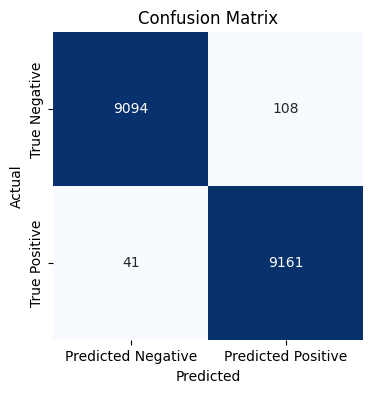

(0.991903933927407,
 np.float64(0.991903933927407),
 np.float64(0.9955444468593784),
 np.float64(0.9882634209954357))

In [ ]:
# Similarity test for train_set
evaluation(pairedLabels[:, 0], train_pred)

## Validation

#### RF

In [ ]:
test_labels = np.asarray(test_labels)

Accuracy:  0.9166666666666666
ROC-AUC:  0.9166666666666665
Sensitivity:  0.9166666666666666
Specificity:  0.9166666666666666


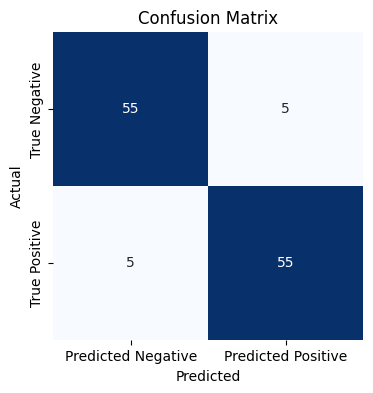

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.925, 0.9666666666666667, 0.9333333333333333, 0.9166666666666666, 0.9166666666666666]
[np.float64(0.925), np.float64(0.9666666666666666), np.float64(0.9333333333333333), np.float64(0.9166666666666666), np.float64(0.9166666666666665)]
[np.float64(0.9666666666666667), np.float64(0.9833333333333333), np.float64(1.0), np.float64(0.9333333333333333), np.float64(0.9166666666666666)]
[np.float64(0.8833333333333333), np.float64(0.95), np.float64(0.8666666666666667), np.float64(0.9), np.float64(0.9166666666666666)]


#### SVM

Accuracy:  0.9166666666666666
ROC-AUC:  0.9166666666666665
Sensitivity:  0.9166666666666666
Specificity:  0.9166666666666666


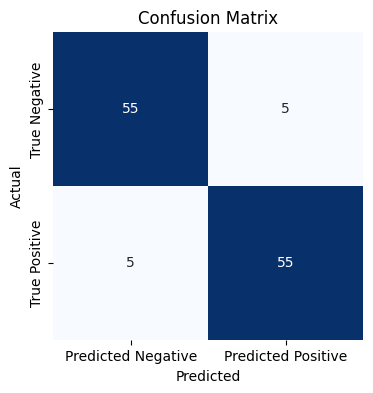

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.925, 0.9, 0.8916666666666667, 0.925, 0.9166666666666666]
[np.float64(0.9249999999999999), np.float64(0.9), np.float64(0.8916666666666666), np.float64(0.9249999999999999), np.float64(0.9166666666666665)]
[np.float64(0.95), np.float64(0.9333333333333333), np.float64(0.9166666666666666), np.float64(0.95), np.float64(0.9166666666666666)]
[np.float64(0.9), np.float64(0.8666666666666667), np.float64(0.8666666666666667), np.float64(0.9), np.float64(0.9166666666666666)]


#### XGBoost

Accuracy:  0.9333333333333333
ROC-AUC:  0.9333333333333333
Sensitivity:  0.9333333333333333
Specificity:  0.9333333333333333


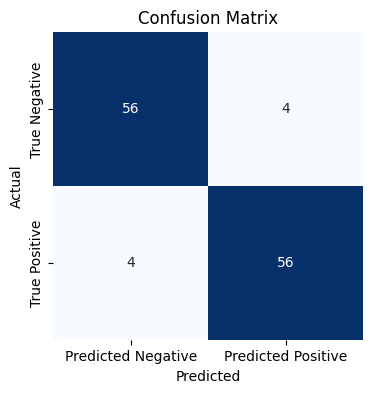

In [ ]:
acc, auc, sen, spc = evaluation(test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.925, 0.9666666666666667, 0.9416666666666667, 0.9333333333333333, 0.9333333333333333]
[np.float64(0.925), np.float64(0.9666666666666666), np.float64(0.9416666666666668), np.float64(0.9333333333333333), np.float64(0.9333333333333333)]
[np.float64(0.9666666666666667), np.float64(0.9833333333333333), np.float64(0.9833333333333333), np.float64(0.9333333333333333), np.float64(0.9333333333333333)]
[np.float64(0.8833333333333333), np.float64(0.95), np.float64(0.9), np.float64(0.9333333333333333), np.float64(0.9333333333333333)]


#### Triplet NN

In [ ]:
test_labels = np.asarray(test_labels)
train_labels = np.asarray(train_labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test = RS_splitter(test_set, test_labels[:, 1])

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

60
2521
60
2521


In [ ]:
x0_train, x1_train = RS_splitter(train_set, train_labels[:, 1])

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1881
2521
4626
2521


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions


for i in x0_test:                     #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])


for i in x1_test:
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :1640],
                           data[:, 1640:(1640+1640)]],
                           data[:, (1640+1640):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])

##### TSA_Net evaluation

(Similarity test)

Accuracy:  0.9170892884585831
ROC-AUC:  0.917089288458583
Sensitivity:  0.9362225295835255
Specificity:  0.8979560473336407


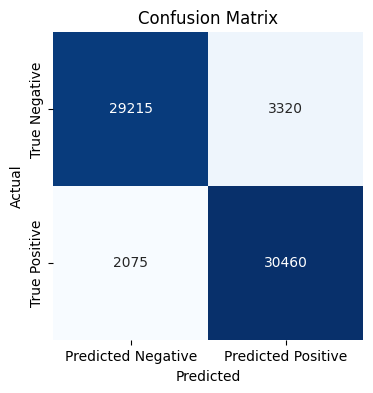

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9235438758260335, 0.9663285692331336, 0.8930843706777317, 0.956569847856155, 0.9170892884585831]
[np.float64(0.9235438758260335), np.float64(0.9663285692331335), np.float64(0.8930843706777317), np.float64(0.956569847856155), np.float64(0.917089288458583)]
[np.float64(0.9483633010603965), np.float64(0.9632088520055325), np.float64(0.9597971415398802), np.float64(0.9744275395727678), np.float64(0.9362225295835255)]
[np.float64(0.8987244505916705), np.float64(0.9694482864607346), np.float64(0.8263715998155832), np.float64(0.9387121561395421), np.float64(0.8979560473336407)]


##### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.9333333333333333
ROC-AUC:  0.9333333333333332
Sensitivity:  0.9166666666666666
Specificity:  0.95


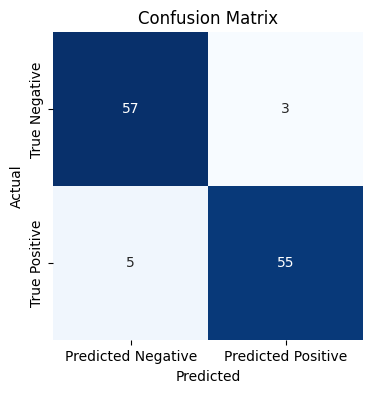

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.9333333333333333, 0.9666666666666667, 0.9166666666666666, 0.925, 0.9333333333333333]
[np.float64(0.9333333333333335), np.float64(0.9666666666666667), np.float64(0.9166666666666666), np.float64(0.9249999999999999), np.float64(0.9333333333333332)]
[np.float64(0.9666666666666667), np.float64(1.0), np.float64(0.9833333333333333), np.float64(0.95), np.float64(0.9166666666666666)]
[np.float64(0.9), np.float64(0.9333333333333333), np.float64(0.85), np.float64(0.9), np.float64(0.95)]


# Results

## RF

In [ ]:
print("Average accuracy: ", sum(rf_acc)/len(rf_acc))
print("Average AUC: ", sum(rf_auc)/len(rf_auc))
print("Average sensitivity: ", sum(rf_sen)/len(rf_sen))
print("Average specificity: ", sum(rf_spc)/len(rf_spc))

Average accuracy:  0.9316666666666666
Average AUC:  0.9316666666666666
Average sensitivity:  0.9600000000000002
Average specificity:  0.9033333333333333


## SVM

In [ ]:
print("Average accuracy: ", sum(svm_acc)/len(svm_acc))
print("Average AUC: ", sum(svm_auc)/len(svm_auc))
print("Average sensitivity: ", sum(svm_sen)/len(svm_sen))
print("Average specificity: ", sum(svm_spc)/len(svm_spc))

Average accuracy:  0.9116666666666667
Average AUC:  0.9116666666666667
Average sensitivity:  0.9333333333333333
Average specificity:  0.89


## XGB

In [ ]:
print("Average accuracy: ", sum(xgb_acc)/len(xgb_acc))
print("Average AUC: ", sum(xgb_auc)/len(xgb_auc))
print("Average sensitivity: ", sum(xgb_sen)/len(xgb_sen))
print("Average specificity: ", sum(xgb_spc)/len(xgb_spc))

Average accuracy:  0.9400000000000001
Average AUC:  0.9400000000000001
Average sensitivity:  0.96
Average specificity:  0.9200000000000002


## TripSimAcin_AMR

In [ ]:
print("Average accuracy: ", sum(nn_acc)/len(nn_acc))
print("Average AUC: ", sum(nn_auc)/len(nn_auc))
print("Average sensitivity: ", sum(nn_sen)/len(nn_sen))
print("Average specificity: ", sum(nn_spc)/len(nn_spc))

Average accuracy:  0.9349999999999999
Average AUC:  0.9349999999999999
Average sensitivity:  0.9633333333333335
Average specificity:  0.9066666666666666


## TSA_Net

In [ ]:
print("Average accuracy: ", sum(sim_acc)/len(sim_acc))
print("Average AUC: ", sum(sim_auc)/len(sim_auc))
print("Average sensitivity: ", sum(sim_sen)/len(sim_sen))
print("Average specificity: ", sum(sim_spc)/len(sim_spc))

Average accuracy:  0.9313231904103274
Average AUC:  0.9313231904103272
Average sensitivity:  0.9564038727524204
Average specificity:  0.9062425080682341


In [ ]:
avg_acc = [sum(rf_acc)/len(rf_acc), sum(svm_acc)/len(svm_acc), sum(xgb_acc)/len(xgb_acc), sum(nn_acc)/len(nn_acc)]
print(avg_acc)

[0.9316666666666666, 0.9116666666666667, 0.9400000000000001, 0.9349999999999999]


In [ ]:
avg_auc = [sum(rf_auc)/len(rf_auc), sum(svm_auc)/len(svm_auc), sum(xgb_auc)/len(xgb_auc), sum(nn_auc)/len(nn_auc)]
print(avg_auc)

[np.float64(0.9316666666666666), np.float64(0.9116666666666667), np.float64(0.9400000000000001), np.float64(0.9349999999999999)]


In [ ]:
avg_sen = [sum(rf_sen)/len(rf_sen), sum(svm_sen)/len(svm_sen), sum(xgb_sen)/len(xgb_sen), sum(nn_sen)/len(nn_sen)]
print(avg_sen)

[np.float64(0.9600000000000002), np.float64(0.9333333333333333), np.float64(0.96), np.float64(0.9633333333333335)]


In [ ]:
avg_spc = [sum(rf_spc)/len(rf_spc), sum(svm_spc)/len(svm_spc), sum(xgb_spc)/len(xgb_spc), sum(nn_spc)/len(nn_spc)]
print(avg_spc)

[np.float64(0.9033333333333333), np.float64(0.89), np.float64(0.9200000000000002), np.float64(0.9066666666666666)]


In [ ]:
import pandas as pd

data = [avg_acc, avg_auc, avg_sen, avg_spc]

results = pd.DataFrame(data, columns=['RF', 'SVM', 'XGB', 'NN'], index=['ACC', 'AUC', 'SEN', 'SPC'])

results

,RF,SVM,XGB,NN
ACC,0.931667,0.911667,0.94,0.935000
AUC,0.931667,0.911667,0.94,0.935000
SEN,0.960000,0.933333,0.96,0.963333
SPC,0.903333,0.890000,0.92,0.906667
